# 06a · Selección del tamaño de ventana para EPCA
**Tesis:** Medición del ciclo financiero en Perú mediante técnicas de reducción dimensional y machine learning

**Objetivo de este notebook:** justificar empíricamente el tamaño de
ventana móvil que se usará en `06_epca.ipynb`, mediante un análisis de
sensibilidad (no un hiperparámetro optimizado contra una etiqueta, ya que
no existe un ground truth de regímenes conocidos).

**Criterio operacionalizado directamente desde el marco conceptual
(sección 2.4 y 6.4):**
- *Estabilidad temporal:* correlación entre cargas factoriales de
  ventanas sucesivas (familia de evidencia "factorial").
- *Sensibilidad:* número de caídas de estabilidad (posibles transiciones)
  detectadas a lo largo de la serie.
- *Validación externa:* si las caídas de estabilidad coinciden con
  episodios financieros documentados (crisis 2008-2009, taper tantrum
  2013, pandemia 2020) -- ver criterio de interpretabilidad, sección 6.1.

**No modifica ningún archivo de `data/processed/` -- solo lee.**

**Salidas:**
- `reports/figures/06a_*.png`
- `data/results/06a_seleccion_ventana_resumen.csv`

## 1. Librerías y carga de datos

In [1]:
import os
os.chdir('..') if os.path.basename(os.getcwd()) == 'notebooks' else None
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_transf = pd.read_csv('data/processed/dataset_estandarizado_trimestral.csv',
                         index_col=0, parse_dates=True)
df_niveles = pd.read_csv('data/processed/dataset_niveles_estandarizado_trimestral.csv',
                          index_col=0, parse_dates=True)

print(f'Transformado: {df_transf.shape[0]} trimestres x {df_transf.shape[1]} variables')
print(f'Niveles:      {df_niveles.shape[0]} trimestres x {df_niveles.shape[1]} variables')

# Episodios financieros documentados, para validacion externa (no como "verdad
# absoluta", sino como referencia de contraste visual)
EPISODIOS = {
    'Crisis financiera global': ('2008-07-01', '2009-06-30'),
    'Taper tantrum': ('2013-04-01', '2013-12-31'),
    'Pandemia COVID-19': ('2020-01-01', '2020-09-30'),
}

Transformado: 72 trimestres x 18 variables
Niveles:      73 trimestres x 20 variables


## 2. Función de análisis de sensibilidad por tamaño de ventana

Para cada tamaño de ventana `w`:
1. Se generan sub-ventanas con paso fijo de 2 trimestres (semestral).
2. En cada ventana se re-estandariza localmente y se ajusta PCA
   (equivalente a un PCA sobre la matriz de correlación de esa ventana,
   consistente con el enfoque de Camiz, Maulucci & Roig, 2010).
3. Se compara la carga factorial del componente de interés entre
   ventanas sucesivas (alineando el signo, ya que el signo de un
   componente principal es arbitrario).
4. La correlación entre cargas sucesivas es la métrica de estabilidad.

In [2]:
def analizar_ventanas(df, tamanos_ventana, paso=2, componente_interes=0, n_componentes=3):
    """
    componente_interes: indice del componente a rastrear (0 = PC1, 1 = PC2, ...)
    Util para excluir PC1 en el caso de 'niveles' (contaminado por tendencia,
    ver 05_pca.ipynb).
    """
    resultados = {}

    for w in tamanos_ventana:
        fechas_centro = []
        cargas_series = []

        inicio = 0
        while inicio + w <= len(df):
            ventana = df.iloc[inicio:inicio + w]
            ventana_std = StandardScaler().fit_transform(ventana)

            pca = PCA(n_components=min(n_componentes, ventana.shape[1]), random_state=42)
            pca.fit(ventana_std)
            carga = pca.components_[componente_interes]

            fechas_centro.append(ventana.index[w // 2])
            cargas_series.append(carga)

            inicio += paso

        # Alinear signo (arbitrario en PCA) respecto a la ventana anterior
        cargas_alineadas = [cargas_series[0]]
        for c in cargas_series[1:]:
            corr_directa = np.corrcoef(c, cargas_alineadas[-1])[0, 1]
            cargas_alineadas.append(c if corr_directa >= 0 else -c)

        # Estabilidad = correlacion entre cargas de ventanas consecutivas
        estabilidad = [
            np.corrcoef(cargas_alineadas[i], cargas_alineadas[i + 1])[0, 1]
            for i in range(len(cargas_alineadas) - 1)
        ]
        fechas_estabilidad = fechas_centro[1:]

        resultados[w] = {
            'fechas': fechas_estabilidad,
            'estabilidad': estabilidad,
            'n_ventanas': len(cargas_series),
        }

    return resultados

## 3. Ejecutar la grilla de tamaños de ventana (datos transformados)

In [3]:
# Grilla acotada por dos limites:
# - MINIMO: debe cumplir n > p (p = numero de variables, ~16 en el dataset
#   transformado) para que la matriz de correlacion no sea singular. Se usa
#   20 como piso (n=20 > p=16, con margen minimo), no 16 (n=p, degenerado).
# - MAXIMO: ~40 trimestres (10 anios), por debajo de la duracion tipica de un
#   ciclo financiero completo (Drehmann et al. 2012: 8-20 anios / 32-80 trimestres).
# LIMITACION RECONOCIDA: con solo 72 trimestres totales (18 anios) de dataset
# final, ninguna ventana de esta grilla alcanza la regla practica de 5-10x p
# (80-160 obs.) recomendada por la literatura de analisis multivariado
# (Jolliffe, 2002). Se documenta como limitacion de tamano de muestra, no se
# oculta ni se fuerza el diseno para evitarla.
TAMANOS_VENTANA = [20, 24, 28, 32, 36, 40]
PASO = 2

resultados_transf = analizar_ventanas(df_transf, TAMANOS_VENTANA, paso=PASO, componente_interes=0)

for w, r in resultados_transf.items():
    print(f'Ventana {w} trimestres: {r["n_ventanas"]} ventanas generadas, '
          f'estabilidad promedio = {np.mean(r["estabilidad"]):.3f}')

Ventana 20 trimestres: 27 ventanas generadas, estabilidad promedio = 0.885
Ventana 24 trimestres: 25 ventanas generadas, estabilidad promedio = 0.921
Ventana 28 trimestres: 23 ventanas generadas, estabilidad promedio = 0.913
Ventana 32 trimestres: 21 ventanas generadas, estabilidad promedio = 0.895
Ventana 36 trimestres: 19 ventanas generadas, estabilidad promedio = 0.898
Ventana 40 trimestres: 17 ventanas generadas, estabilidad promedio = 0.922


## 4. Trade-off estabilidad vs. sensibilidad

- **Estabilidad promedio:** más alta = ventanas más consistentes entre sí
  (menos sensible a cambios reales, riesgo de "aplanar" transiciones).
- **Sensibilidad:** número de caídas de estabilidad por debajo de un
  umbral (promedio - 1 desviación estándar) = posibles transiciones
  detectadas. Más caídas no es necesariamente mejor -- puede ser ruido.

In [4]:
resumen = []
for w, r in resultados_transf.items():
    estab = np.array(r['estabilidad'])
    umbral = estab.mean() - estab.std()
    n_caidas = int((estab < umbral).sum())
    resumen.append({
        'ventana_trimestres': w,
        'ventana_anios': round(w / 4, 1),
        'n_ventanas_generadas': r['n_ventanas'],
        'estabilidad_promedio': round(estab.mean(), 3),
        'estabilidad_std': round(estab.std(), 3),
        'n_caidas_detectadas': n_caidas,
    })

df_resumen = pd.DataFrame(resumen)
df_resumen

,ventana_trimestres,ventana_anios,n_ventanas_generadas,estabilidad_promedio,estabilidad_std,n_caidas_detectadas
0,20,5.0,27,0.885,0.228,3
1,24,6.0,25,0.921,0.149,4
2,28,7.0,23,0.913,0.179,3
3,32,8.0,21,0.895,0.214,2
4,36,9.0,19,0.898,0.224,2
5,40,10.0,17,0.922,0.147,3


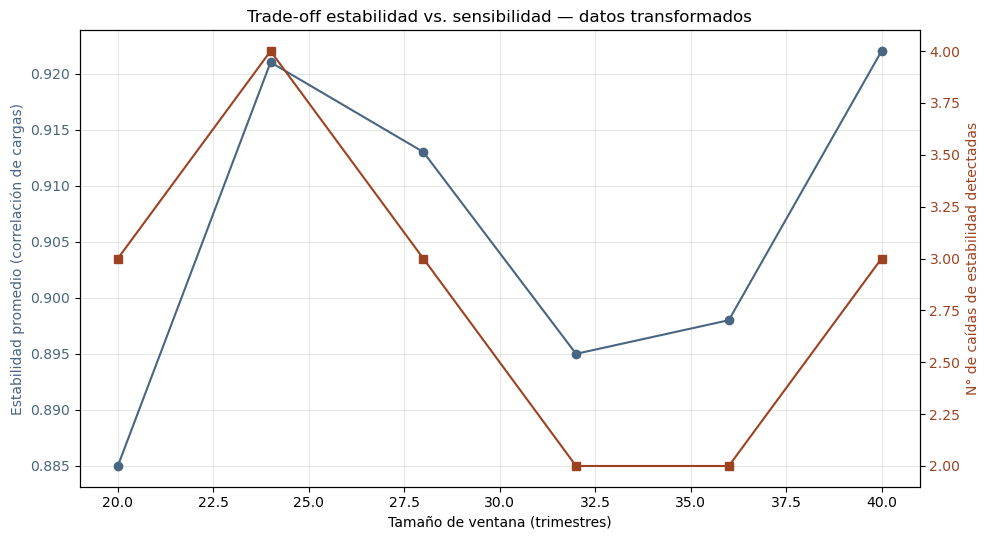

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 5.5))

color1 = '#486581'
ax1.plot(df_resumen['ventana_trimestres'], df_resumen['estabilidad_promedio'],
         marker='o', color=color1, label='Estabilidad promedio')
ax1.set_xlabel('Tamaño de ventana (trimestres)')
ax1.set_ylabel('Estabilidad promedio (correlación de cargas)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = '#9c4221'
ax2.plot(df_resumen['ventana_trimestres'], df_resumen['n_caidas_detectadas'],
         marker='s', color=color2, label='Caídas detectadas (sensibilidad)')
ax2.set_ylabel('N° de caídas de estabilidad detectadas', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Trade-off estabilidad vs. sensibilidad — datos transformados')
fig.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/06a_tradeoff_estabilidad_sensibilidad.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Validación externa: ¿las caídas de estabilidad coinciden con episodios conocidos?

Se grafica la serie de estabilidad para un subconjunto representativo de
tamaños de ventana (menor, intermedio, mayor), marcando los episodios
financieros documentados como referencia visual.

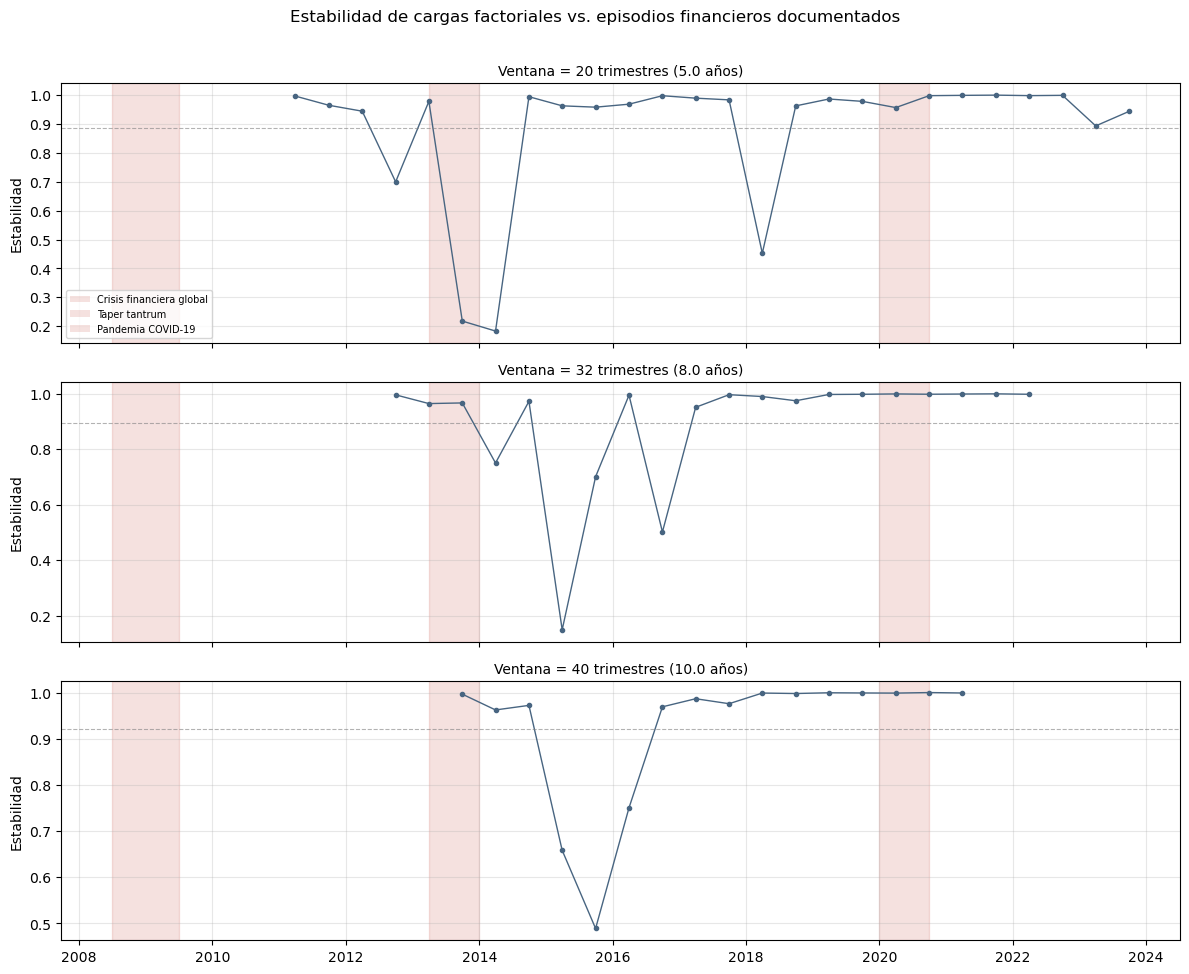

Revisión visual: ¿las caídas de la línea azul (menor estabilidad) caen dentro
de las bandas rojas (episodios conocidos)? Si sí, es evidencia a favor de ese
tamaño de ventana. Si las caídas están dispersas sin relación con las bandas,
es señal de que ese tamaño está capturando ruido, no transiciones reales.


In [6]:
tamanos_a_graficar = [TAMANOS_VENTANA[0], TAMANOS_VENTANA[len(TAMANOS_VENTANA)//2], TAMANOS_VENTANA[-1]]

fig, axes = plt.subplots(len(tamanos_a_graficar), 1, figsize=(12, 3.2 * len(tamanos_a_graficar)), sharex=True)

for ax, w in zip(axes, tamanos_a_graficar):
    r = resultados_transf[w]
    ax.plot(r['fechas'], r['estabilidad'], marker='o', markersize=3, linewidth=1, color='#486581')
    ax.axhline(np.mean(r['estabilidad']), color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

    for nombre, (ini, fin) in EPISODIOS.items():
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color='#c0392b', alpha=0.15)

    ax.set_title(f'Ventana = {w} trimestres ({w/4:.1f} años)', fontsize=10)
    ax.set_ylabel('Estabilidad')
    ax.grid(True, alpha=0.3)

# Leyenda manual para las bandas de episodios
from matplotlib.patches import Patch
leyenda = [Patch(facecolor='#c0392b', alpha=0.15, label=nombre) for nombre in EPISODIOS.keys()]
axes[0].legend(handles=leyenda, loc='lower left', fontsize=7)

plt.suptitle('Estabilidad de cargas factoriales vs. episodios financieros documentados', y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/06a_validacion_episodios.png', dpi=150, bbox_inches='tight')
plt.show()

print('Revisión visual: ¿las caídas de la línea azul (menor estabilidad) caen dentro')
print('de las bandas rojas (episodios conocidos)? Si sí, es evidencia a favor de ese')
print('tamaño de ventana. Si las caídas están dispersas sin relación con las bandas,')
print('es señal de que ese tamaño está capturando ruido, no transiciones reales.')

## 6. Repetir el análisis para niveles estandarizados (excluyendo PC1)

Dado que PC1 en niveles está dominado por tendencia (correlación 0.994
con el tiempo, ver `05_pca.ipynb`), aquí se rastrea **PC2** en lugar de
PC1 (`componente_interes=1`).

In [7]:
resultados_niveles = analizar_ventanas(df_niveles, TAMANOS_VENTANA, paso=PASO, componente_interes=1)

resumen_niveles = []
for w, r in resultados_niveles.items():
    estab = np.array(r['estabilidad'])
    umbral = estab.mean() - estab.std()
    n_caidas = int((estab < umbral).sum())
    resumen_niveles.append({
        'ventana_trimestres': w,
        'ventana_anios': round(w / 4, 1),
        'n_ventanas_generadas': r['n_ventanas'],
        'estabilidad_promedio': round(estab.mean(), 3),
        'estabilidad_std': round(estab.std(), 3),
        'n_caidas_detectadas': n_caidas,
    })

df_resumen_niveles = pd.DataFrame(resumen_niveles)
df_resumen_niveles

,ventana_trimestres,ventana_anios,n_ventanas_generadas,estabilidad_promedio,estabilidad_std,n_caidas_detectadas
0,20,5.0,27,0.827,0.228,4
1,24,6.0,25,0.869,0.226,3
2,28,7.0,23,0.872,0.223,3
3,32,8.0,21,0.873,0.218,2
4,36,9.0,19,0.853,0.244,2
5,40,10.0,17,0.875,0.203,2


## 7. Decisión final y guardado

Con base en las tablas y gráficos anteriores, define aquí el tamaño de
ventana elegido para `06_epca.ipynb`, con una justificación de una línea
que puedas copiar directamente al capítulo metodológico.

In [8]:
# AJUSTAR manualmente despues de revisar las secciones 4-6:
VENTANA_ELEGIDA = None  # ej. 24
JUSTIFICACION = (
    'Completar tras revisar el trade-off estabilidad/sensibilidad y la '
    'coincidencia con episodios conocidos (secciones 4-5).'
)

print(f'Ventana elegida: {VENTANA_ELEGIDA} trimestres')
print(f'Justificación: {JUSTIFICACION}')

Ventana elegida: None trimestres
Justificación: Completar tras revisar el trade-off estabilidad/sensibilidad y la coincidencia con episodios conocidos (secciones 4-5).


In [9]:
os.makedirs('data/results', exist_ok=True)

df_resumen['dataset'] = 'transformado_estandarizado'
df_resumen_niveles['dataset'] = 'niveles_estandarizado (PC2)'

df_resumen_final = pd.concat([df_resumen, df_resumen_niveles], ignore_index=True)
df_resumen_final.to_csv('data/results/06a_seleccion_ventana_resumen.csv', index=False)

print('Guardado: data/results/06a_seleccion_ventana_resumen.csv')
df_resumen_final

Guardado: data/results/06a_seleccion_ventana_resumen.csv


,ventana_trimestres,ventana_anios,n_ventanas_generadas,estabilidad_promedio,estabilidad_std,n_caidas_detectadas,dataset
0,20,5.0,27,0.885,0.228,3,transformado_estandarizado
1,24,6.0,25,0.921,0.149,4,transformado_estandarizado
2,28,7.0,23,0.913,0.179,3,transformado_estandarizado
3,32,8.0,21,0.895,0.214,2,transformado_estandarizado
4,36,9.0,19,0.898,0.224,2,transformado_estandarizado
5,40,10.0,17,0.922,0.147,3,transformado_estandarizado
6,20,5.0,27,0.827,0.228,4,niveles_estandarizado (PC2)
7,24,6.0,25,0.869,0.226,3,niveles_estandarizado (PC2)
8,28,7.0,23,0.872,0.223,3,niveles_estandarizado (PC2)
9,32,8.0,21,0.873,0.218,2,niveles_estandarizado (PC2)
